# DATA 620 Assignment 6 - Davis Southern Club Women

## Introduction

The Davis Southern Club Women dataset is a bipartite graph of a number of women and the clubs they went to. On face value, it is very simple, but there are a few quirks involved. In addition to examining standard metrics, we project a bipartite graph in order to examine complex relationships between the women and club nodes.

In [ ]:
# imports, including the base data and general shape details
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import itertools
from scipy.stats import spearmanr
import numpy as np
from matplotlib_venn import venn2

G = nx.davis_southern_women_graph()
women = G.graph['top']
clubs = G.graph['bottom']
W = bipartite.weighted_projected_graph(G, women)
print(f'Number of nodes: {G.number_of_nodes()}\nNumber of edges: {G.number_of_edges()}')
print(f'Number of women: {len(women)}')
print(f'Number of clubs: {len(clubs)}')



Number of nodes: 32
Number of edges: 89
Number of women: 18
Number of clubs: 14


There are 32 total nodes, divided into 18 women and 14 clubs. A total of 89 edges connect the women and clubs.

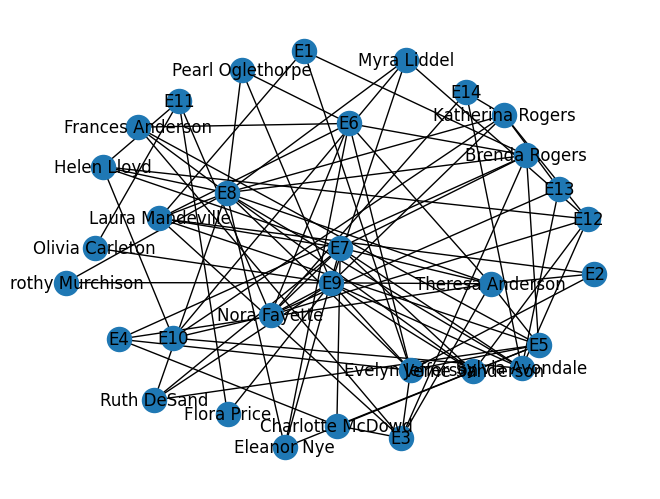

In [ ]:
plt.close()
pos = nx.spring_layout(G, k = 2, seed=123)
nx.draw(G, pos, with_labels = True)
plt.show()


At a glance the women and clubs are very scattered. The full combined graph can be hard to glean information from because The connections for the women and clubs rely on the other type of node rather than being connected on their own. In other words, clubs do not directly connect to other clubs and women do not directly connect to other women. **This visual depicts why we need to project the graph.**

### Centrality Measures

We will start by comparing degree centralities.

In [ ]:
print('Degree Centrality for Women')
degree_women_unweighted = []
for w in women:
    degree_women_unweighted.append((W.degree(w), w))
for degree, w in sorted(degree_women_unweighted, key=lambda item: item[0], reverse=True):
    print(f'{degree} {w}')

print('\nWeighted Degree Centrality for Women')
degree_women_weighted = []
for w in women:
    degree_women_weighted.append((W.degree(w, weight='weight'), w))
for degree, w in sorted(degree_women_weighted, key=lambda item: item[0], reverse=True):
    print(f'{degree} {w}')

Degree Centrality for Women
17 Evelyn Jefferson
17 Theresa Anderson
17 Ruth DeSand
17 Verne Sanderson
17 Sylvia Avondale
17 Nora Fayette
17 Helen Lloyd
16 Pearl Oglethorpe
16 Myra Liddel
16 Katherina Rogers
16 Dorothy Murchison
15 Laura Mandeville
15 Brenda Rogers
15 Frances Anderson
15 Eleanor Nye
12 Olivia Carleton
12 Flora Price
11 Charlotte McDowd

Weighted Degree Centrality for Women
57 Theresa Anderson
50 Evelyn Jefferson
46 Brenda Rogers
46 Sylvia Avondale
45 Laura Mandeville
43 Nora Fayette
40 Ruth DeSand
38 Verne Sanderson
37 Katherina Rogers
36 Eleanor Nye
34 Helen Lloyd
33 Myra Liddel
32 Frances Anderson
31 Pearl Oglethorpe
24 Charlotte McDowd
24 Dorothy Murchison
14 Olivia Carleton
14 Flora Price


The weighted degree centrality shows that Theresa Anderson's connections typically have higher weights than the other extremely connected women. Charlotte McDowd also has a much higher weighted degree centrality (`WDC`)than her unweighted (`DC`) version.

There is a lot to unpack, so let's visualize this in a way that is easier to analyze. Viewing the discrepancy between weighted and unweighted allows us to find outliers.

                   Unweighted Degree  Weighted Degree
Theresa Anderson                  17               57
Evelyn Jefferson                  17               50
Sylvia Avondale                   17               46
Nora Fayette                      17               43
Ruth DeSand                       17               40
Verne Sanderson                   17               38
Helen Lloyd                       17               34
Katherina Rogers                  16               37
Myra Liddel                       16               33
Pearl Oglethorpe                  16               31
Dorothy Murchison                 16               24
Brenda Rogers                     15               46
Laura Mandeville                  15               45
Eleanor Nye                       15               36
Frances Anderson                  15               32
Olivia Carleton                   12               14
Flora Price                       12               14
Charlotte McDowd            

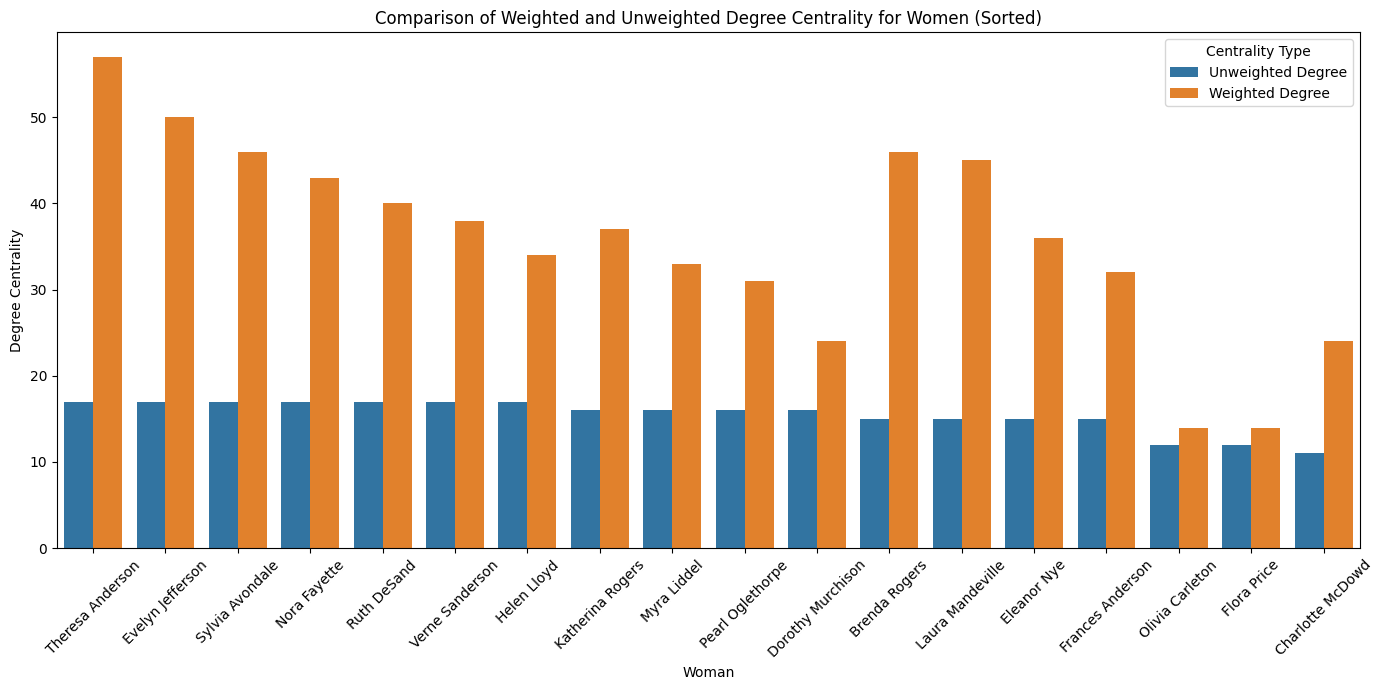

In [ ]:
# Create a dictionary to map each woman's name to her unweighted degree centrality
unweighted_degree_dict = {w: degree for degree, w in degree_women_unweighted}

# Create another dictionary to map each woman's name to her weighted degree centrality
weighted_degree_dict = {w: degree for degree, w in degree_women_weighted}

# Create dataframe for all women
centrality_df = pd.DataFrame({
    'Unweighted Degree': pd.Series(unweighted_degree_dict),
    'Weighted Degree': pd.Series(weighted_degree_dict)
})

# Sort the DataFrame first by 'Unweighted Degree' and then by 'Weighted Degree' for tie-breaking
sorted_centrality_df = centrality_df.sort_values(by=['Unweighted Degree', 'Weighted Degree'], ascending=[False, False])

print(sorted_centrality_df)

# Melt the sorted_centrality_df DataFrame to transform it into a long format
melted_centrality_df = sorted_centrality_df.reset_index().rename(columns={'index': 'Woman'}).melt(
    id_vars=['Woman'],
    var_name='Centrality Type',
    value_name='Degree'
)

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Woman', y='Degree', hue='Centrality Type', data=melted_centrality_df)
plt.xlabel('Woman')
plt.ylabel('Degree Centrality')
plt.title('Comparison of Weighted and Unweighted Degree Centrality for Women (Sorted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We gain more insights now such as Katherina Rogers's `WDC` outperforming her `DC` relative to Helen Lloyd. Some other key outperformers include Brenda Rogers, Laura Mandeville, and Eleanor Nye. There are enough differences that we should test to make sure our `WDC` is still correlated.

In [ ]:
# Calculate Spearman's Rank Correlation
spearman_corr, p_value = spearmanr(centrality_df['Unweighted Degree'], centrality_df['Weighted Degree'])

print(f'Spearman\'s Rank Correlation between Unweighted and Weighted Degree Centrality: {spearman_corr:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('The correlation is statistically significant.')
else:
    print('The correlation is not statistically significant.')

Spearman's Rank Correlation between Unweighted and Weighted Degree Centrality: 0.6270
P-value: 0.0054
The correlation is statistically significant.


There are no issues with our degree centrality measures. We will use them when appropriate.

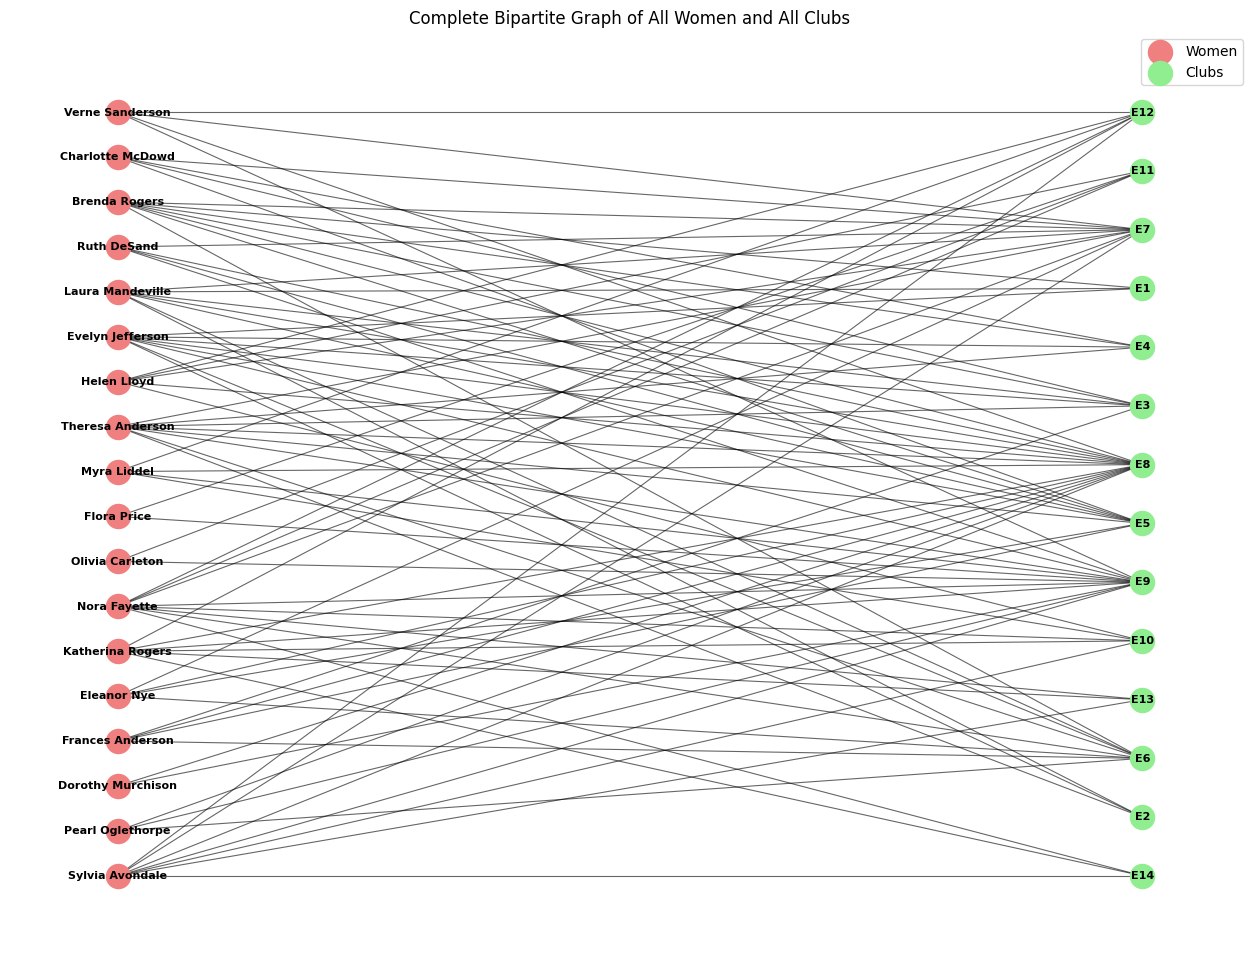

In [ ]:
women_nodes_all = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
club_nodes_all = [n for n, d in G.nodes(data=True) if d['bipartite'] == 1]

# Position the nodes using a bipartite layout
pos_bipartite_all = nx.bipartite_layout(G, women_nodes_all)

# Draw the complete bipartite graph
plt.figure(figsize=(16, 12))
nx.draw_networkx_nodes(G, pos_bipartite_all, nodelist=women_nodes_all, node_color='lightcoral', label='Women', node_size=300)
nx.draw_networkx_nodes(G, pos_bipartite_all, nodelist=club_nodes_all, node_color='lightgreen', label='Clubs', node_size=300)
nx.draw_networkx_edges(G, pos_bipartite_all, width=0.8, alpha=0.6)
nx.draw_networkx_labels(G, pos_bipartite_all, font_size=8, font_weight='bold')

plt.title('Complete Bipartite Graph of All Women and All Clubs')
plt.legend()
plt.axis('off')
plt.show()

Another way we can visualize this graph is by separating out the women and clubs on opposite sides. Every woman goes to multiple clubs and every club has multiple women. It is clearer here that women and clubs are only connected to their own types of nodes through the other.

In [ ]:
betweenness_centrality_women = nx.betweenness_centrality(W)
closeness_centrality_women = nx.closeness_centrality(W)

print('\nBetweenness Centrality for Women:')
for w, bc in sorted(betweenness_centrality_women.items(), key=lambda item: item[1], reverse=True):
    print(f'{w}: {bc:.4f}')

print('\nCloseness Centrality for Women:')
for w, cc in sorted(closeness_centrality_women.items(), key=lambda item: item[1], reverse=True):
    print(f'{w}: {cc:.4f}')


Betweenness Centrality for Women:
Evelyn Jefferson: 0.0101
Theresa Anderson: 0.0101
Ruth DeSand: 0.0101
Verne Sanderson: 0.0101
Sylvia Avondale: 0.0101
Nora Fayette: 0.0101
Helen Lloyd: 0.0101
Pearl Oglethorpe: 0.0053
Myra Liddel: 0.0053
Katherina Rogers: 0.0053
Dorothy Murchison: 0.0053
Laura Mandeville: 0.0027
Brenda Rogers: 0.0027
Frances Anderson: 0.0027
Eleanor Nye: 0.0027
Charlotte McDowd: 0.0000
Olivia Carleton: 0.0000
Flora Price: 0.0000

Closeness Centrality for Women:
Evelyn Jefferson: 1.0000
Theresa Anderson: 1.0000
Ruth DeSand: 1.0000
Verne Sanderson: 1.0000
Sylvia Avondale: 1.0000
Nora Fayette: 1.0000
Helen Lloyd: 1.0000
Pearl Oglethorpe: 0.9444
Myra Liddel: 0.9444
Katherina Rogers: 0.9444
Dorothy Murchison: 0.9444
Laura Mandeville: 0.8947
Brenda Rogers: 0.8947
Frances Anderson: 0.8947
Eleanor Nye: 0.8947
Olivia Carleton: 0.7727
Flora Price: 0.7727
Charlotte McDowd: 0.7391


All women show a low betweenness centrality here. No singular woman has a high impact on the connections of the graph if she were to be removed.

However, 7 women show 1.0 closeness centrality and all have relatively higher betweenness centrality values than the remaining 11. That means despite no single woman being extremely critical to connecting the group together, all of them are actually closely connected. This group of 7 matches the order of `DC`, albeit not `WDC`.

### The Top 7 Women

First, let's collect all the unique clubs attended by these 7 selected women.

In [ ]:
# Get the top 7 women
selected_women = [
    'Evelyn Jefferson',
    'Theresa Anderson',
    'Ruth DeSand',
    'Verne Sanderson',
    'Sylvia Avondale',
    'Nora Fayette',
    'Helen Lloyd'
]

# Get all unique clubs associated with these 7 women
clubs_of_selected_women = set()
for woman in selected_women:
    # Find all neighbors (clubs) for each selected woman
    clubs_of_selected_women.update(G.neighbors(woman))

print('Unique clubs attended by the top 7 women:')
for club in sorted(list(clubs_of_selected_women)):
    print(f'- {club}')

print(f'\nTotal number of unique clubs attended by these 7 women: {len(clubs_of_selected_women)}')

Unique clubs attended by the top 7 women:
- E1
- E10
- E11
- E12
- E13
- E14
- E2
- E3
- E4
- E5
- E6
- E7
- E8
- E9

Total number of unique clubs attended by these 7 women: 14


These 7 women collectively went to all 14 clubs. This is a unique subgraph because it depicts one of the best clusters of women to account for all clubs.

Let's visualize the connection between these 7 women.

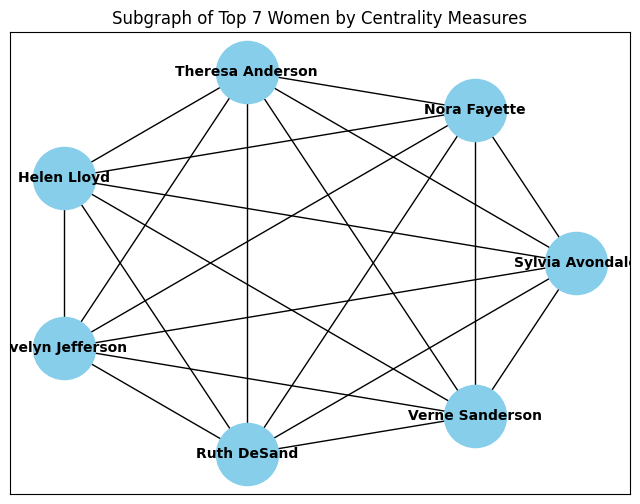

In [ ]:
# Create the subgraph from the projected graph W
subgraph_of_top_women = W.subgraph(selected_women)

# Draw the subgraph
plt.figure(figsize=(8, 6))
pos_sub = nx.circular_layout(subgraph_of_top_women)
nx.draw_networkx(subgraph_of_top_women, pos_sub, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_weight='bold')
plt.title('Subgraph of Top 7 Women by Centrality Measures')
plt.show()

This is perfectly balanced. They are all connected to each other like a clique.

In [ ]:
# Save for Gephi analysis
# nx.write_gexf(G, 'womens_club.gexf')

In [ ]:
women_club_memberships = {}
for woman in selected_women:
    women_club_memberships[woman] = set(G.neighbors(woman))

print('Clubs of top 7 women:')
for woman, clubs_set in women_club_memberships.items():
    print(f'{woman}: {clubs_set}')

pairwise_overlaps = []

print('\nPairwise Club Overlaps for Selected Women:')
for woman1, woman2 in itertools.combinations(selected_women, 2):
    clubs_woman1 = women_club_memberships[woman1]
    clubs_woman2 = women_club_memberships[woman2]

    shared_clubs = clubs_woman1 & clubs_woman2
    num_shared_clubs = len(shared_clubs)

    print(f'{woman1} and {woman2} share {num_shared_clubs} clubs.')
    pairwise_overlaps.append(((woman1, woman2), num_shared_clubs))

Clubs of top 7 women:
Evelyn Jefferson: {'E2', 'E6', 'E9', 'E5', 'E8', 'E3', 'E4', 'E1'}
Theresa Anderson: {'E6', 'E2', 'E9', 'E5', 'E8', 'E3', 'E4', 'E7'}
Ruth DeSand: {'E7', 'E9', 'E8', 'E5'}
Verne Sanderson: {'E7', 'E9', 'E12', 'E8'}
Sylvia Avondale: {'E14', 'E13', 'E10', 'E9', 'E8', 'E7', 'E12'}
Nora Fayette: {'E14', 'E6', 'E13', 'E10', 'E9', 'E7', 'E11', 'E12'}
Helen Lloyd: {'E10', 'E8', 'E7', 'E11', 'E12'}

Pairwise Club Overlaps for Selected Women:
Evelyn Jefferson and Theresa Anderson share 7 clubs.
Evelyn Jefferson and Ruth DeSand share 3 clubs.
Evelyn Jefferson and Verne Sanderson share 2 clubs.
Evelyn Jefferson and Sylvia Avondale share 2 clubs.
Evelyn Jefferson and Nora Fayette share 2 clubs.
Evelyn Jefferson and Helen Lloyd share 1 clubs.
Theresa Anderson and Ruth DeSand share 4 clubs.
Theresa Anderson and Verne Sanderson share 3 clubs.
Theresa Anderson and Sylvia Avondale share 3 clubs.
Theresa Anderson and Nora Fayette share 3 clubs.
Theresa Anderson and Helen Lloyd shar

Evelyn Jefferson and Theresa Anderson show the most overlap with 7 clubs. Helen Lloyd only shares 1 club with Evelynn Anderson, but that likely increased her `WDC` heavily.

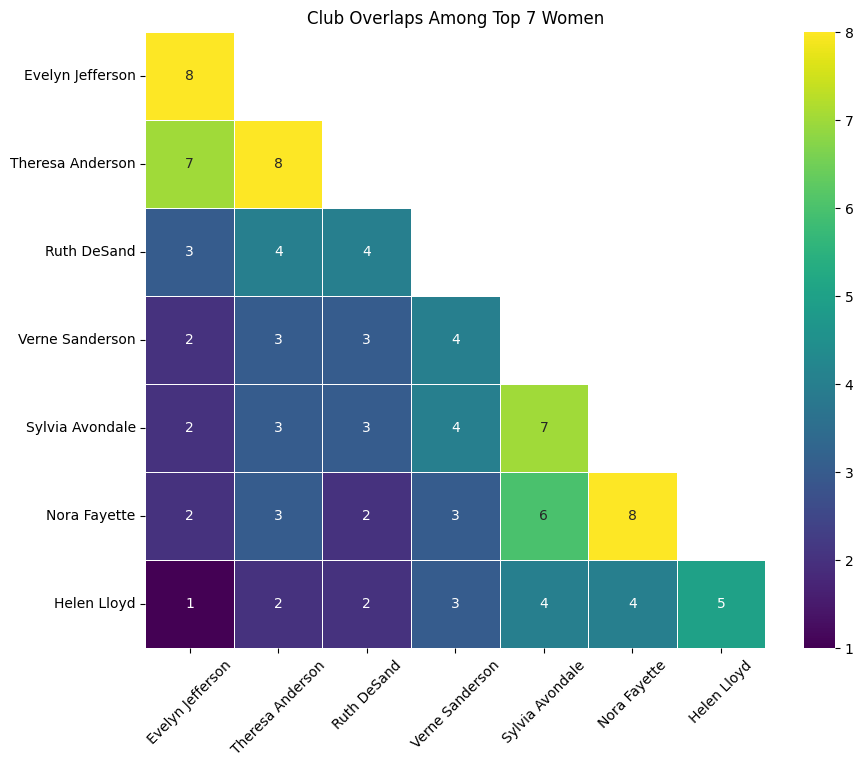

In [ ]:
# Create an empty DataFrame for the overlap matrix
overlap_matrix = pd.DataFrame(0, index=selected_women, columns=selected_women)

# Populate the off-diagonal elements with pairwise overlaps
for (woman1, woman2), num_shared_clubs in pairwise_overlaps:
    overlap_matrix.loc[woman1, woman2] = num_shared_clubs
    overlap_matrix.loc[woman2, woman1] = num_shared_clubs

# Populate the diagonal with the total number of clubs each woman attends
for woman in selected_women:
    overlap_matrix.loc[woman, woman] = len(women_club_memberships[woman])

# Remove duplicate squares for clarity
mask = np.triu(np.ones_like(overlap_matrix, dtype=bool), k=1)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, cmap='viridis', fmt='d', linewidths=.5, mask=mask)
plt.xticks(rotation=45)
plt.title('Club Overlaps Among Top 7 Women')
plt.show()

From the heatmap we can see that Nora Fayette and Sylvia Avondale also were in the same club often. This was available in the previous data, but more obvious when visualized.

In [ ]:
non_top_7_women = [woman for woman in women if woman not in selected_women]
non_top_7_women_club_memberships = {}
for woman in non_top_7_women:
    non_top_7_women_club_memberships[woman] = set(G.neighbors(woman))

non_top_7_pairwise_overlaps = []

for woman1, woman2 in itertools.combinations(non_top_7_women, 2):
    clubs_woman1 = non_top_7_women_club_memberships[woman1]
    clubs_woman2 = non_top_7_women_club_memberships[woman2]

    shared_clubs = clubs_woman1 & clubs_woman2
    num_shared_clubs = len(shared_clubs)

    non_top_7_pairwise_overlaps.append(((woman1, woman2), num_shared_clubs))

# Sort the pairwise overlaps from highest to lowest shared clubs
sorted_overlaps = sorted(non_top_7_pairwise_overlaps, key=lambda item: item[1], reverse=True)

for (woman1, woman2), num_shared_clubs in sorted_overlaps:
    print(f'{woman1} and {woman2} share {num_shared_clubs} clubs.')

Laura Mandeville and Brenda Rogers share 6 clubs.
Laura Mandeville and Frances Anderson share 4 clubs.
Laura Mandeville and Eleanor Nye share 4 clubs.
Brenda Rogers and Charlotte McDowd share 4 clubs.
Brenda Rogers and Frances Anderson share 4 clubs.
Brenda Rogers and Eleanor Nye share 4 clubs.
Myra Liddel and Katherina Rogers share 4 clubs.
Laura Mandeville and Charlotte McDowd share 3 clubs.
Frances Anderson and Eleanor Nye share 3 clubs.
Laura Mandeville and Pearl Oglethorpe share 2 clubs.
Brenda Rogers and Pearl Oglethorpe share 2 clubs.
Charlotte McDowd and Frances Anderson share 2 clubs.
Charlotte McDowd and Eleanor Nye share 2 clubs.
Frances Anderson and Pearl Oglethorpe share 2 clubs.
Eleanor Nye and Pearl Oglethorpe share 2 clubs.
Pearl Oglethorpe and Myra Liddel share 2 clubs.
Pearl Oglethorpe and Katherina Rogers share 2 clubs.
Pearl Oglethorpe and Dorothy Murchison share 2 clubs.
Myra Liddel and Dorothy Murchison share 2 clubs.
Katherina Rogers and Dorothy Murchison share 2

Despite having lower centrality measures than the women from the top 7, Laura Mandeville and Brenda Rogers notably share 6 clubs. They seem to be closely knit despite not necessarily joining all clubs. Recall our `WDC` rankings however.

Weighted Degree Centrality for Women
*  57 Theresa Anderson
*  50 Evelyn Jefferson
*  46 Brenda Rogers
*  46 Sylvia Avondale
*  45 Laura Mandeville

`WDC` bumped those two up despite their lower `DC` relative to some other women. This means their unusually high weight is a product of their close-knit club attendance.

There is one other idea we can test here. Which other women might also go to clubs together more?

### The Rogers and Andersons

The idea that some women might go to clubs together implies that there should be a link between them. We do not have a lot of information about these women besides their club attendance... and their names. Notably, we have Brenda and Katherina Rogers and Theresa and Frances Anderson. Taking the information we already have been using, we can make an educated guess if there are potential correlations.

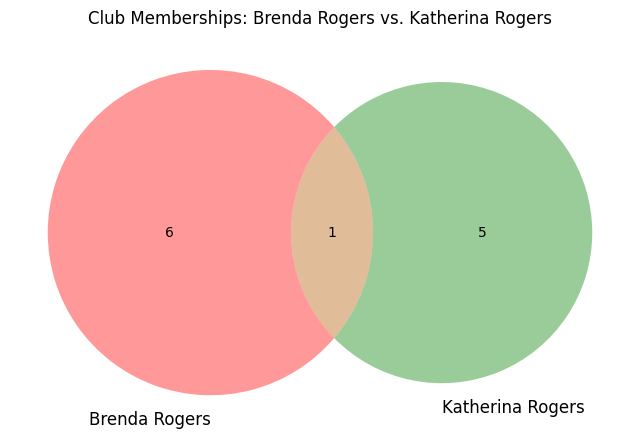

In [ ]:
brenda_rogers_clubs = set(G.neighbors('Brenda Rogers'))
katherina_rogers_clubs = set(G.neighbors('Katherina Rogers'))
brenda_katherina_shared_clubs = len(brenda_rogers_clubs.intersection(katherina_rogers_clubs))
print(f'Brenda Rogers and Katherina Rogers share {brenda_katherina_shared_clubs} club(s).')
print(f'Brenda Rogers attends {len(brenda_rogers_clubs)} clubs in total.')
print(f'Katherina Rogers attends {len(katherina_rogers_clubs)} clubs in total.\n')

rogers_unique_brenda = len(brenda_rogers_clubs - katherina_rogers_clubs)
rogers_unique_katherina = len(katherina_rogers_clubs - brenda_rogers_clubs)
plt.figure(figsize=(8, 6))
venn2(subsets=(rogers_unique_brenda, rogers_unique_katherina, brenda_katherina_shared_clubs),
      set_labels=('Brenda Rogers', 'Katherina Rogers'))
plt.title('Club Memberships: Brenda Rogers vs. Katherina Rogers')
plt.show()

The two women named "Rogers" went to 6-7 clubs each, but only shared one club. There does not seem to be a correlation with their names.

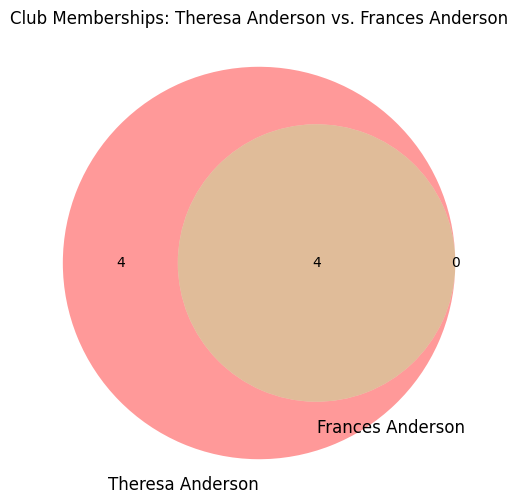

In [ ]:
theresa_anderson_clubs = set(G.neighbors('Theresa Anderson'))
frances_anderson_clubs = set(G.neighbors('Frances Anderson'))
theresa_frances_shared_clubs = len(theresa_anderson_clubs.intersection(frances_anderson_clubs))
print(f'Theresa Anderson and Frances Anderson share {theresa_frances_shared_clubs} club(s).')
print(f'Theresa Anderson attends {len(theresa_anderson_clubs)} clubs in total.')
print(f'Frances Anderson attends {len(frances_anderson_clubs)} clubs in total.')

anderson_unique_theresa = len(theresa_anderson_clubs - frances_anderson_clubs)
anderson_unique_frances = len(frances_anderson_clubs - theresa_anderson_clubs)
plt.figure(figsize=(8, 6))
venn2(subsets=(anderson_unique_theresa, anderson_unique_frances, theresa_frances_shared_clubs),
      set_labels=('Theresa Anderson', 'Frances Anderson'))
plt.title('Club Memberships: Theresa Anderson vs. Frances Anderson')
plt.show()

The two women named "Anderson" do show an interesting connection. Frances Anderson went to only 4 clubs, but all were shared with Theresa Anderson. This highly suggests a relation between them.

### Identifying Cliques

Our work so far has shown the possibility of cliques. NetworkX has tools to find them. Let's see how this compares to what we've determined.

In [83]:
cliques = list(nx.find_cliques(W))

print('Overlap between cliques:')
for i, clique1 in enumerate(cliques):
    for j, clique2 in enumerate(cliques):
        # Only compare unique pairs and avoid self-comparison
        if i < j:
            shared_members = set(clique1) & set(clique2)
            num_shared = len(shared_members)
            print(f'Clique {i+1} and Clique {j+1} share {num_shared} members: {sorted(list(shared_members))}')

Overlap between cliques:
Clique 1 and Clique 2 share 11 members: ['Dorothy Murchison', 'Evelyn Jefferson', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Pearl Oglethorpe', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson', 'Verne Sanderson']
Clique 1 and Clique 3 share 7 members: ['Evelyn Jefferson', 'Helen Lloyd', 'Nora Fayette', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson', 'Verne Sanderson']
Clique 2 and Clique 3 share 11 members: ['Brenda Rogers', 'Eleanor Nye', 'Evelyn Jefferson', 'Frances Anderson', 'Helen Lloyd', 'Laura Mandeville', 'Nora Fayette', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson', 'Verne Sanderson']


The provided functions suggest 3 cliques exist, but with a lot of overlap. If we remove our top 7, we instead get the following:

In [84]:
# Find all cliques
all_cliques = list(nx.find_cliques(W))

# Filter out the selected_women from each clique
filtered_cliques = []
for clique in all_cliques:
    filtered_clique = [woman for woman in clique if woman not in selected_women]
    if len(filtered_clique) > 1: # A clique must have at least 2 members
        filtered_cliques.append(filtered_clique)

print('Overlap between cliques (excluding selected women):')
for i, clique1 in enumerate(filtered_cliques):
    for j, clique2 in enumerate(filtered_cliques):
        if i < j:
            shared_members = set(clique1) & set(clique2)
            num_shared = len(shared_members)
            print(f'Filtered Clique {i+1} and Filtered Clique {j+1} share {num_shared} members: {sorted(list(shared_members))}')

Overlap between cliques (excluding selected women):
Filtered Clique 1 and Filtered Clique 2 share 4 members: ['Dorothy Murchison', 'Katherina Rogers', 'Myra Liddel', 'Pearl Oglethorpe']
Filtered Clique 1 and Filtered Clique 3 share 0 members: []
Filtered Clique 2 and Filtered Clique 3 share 4 members: ['Brenda Rogers', 'Eleanor Nye', 'Frances Anderson', 'Laura Mandeville']


As Clique 1 and Clique 3 do not share any members besides exactly the 7 women who exibited the highest closeness centrality, they are likely the "real" cliques within this group.

In [89]:
clique1_set = set(cliques[0])
clique3_set = set(cliques[2])

unique_to_clique1 = clique1_set - clique3_set
unique_to_clique3 = clique3_set - clique1_set

print(f"Members unique to Clique 1: {sorted(list(unique_to_clique1))}")
print(f"Members unique to Clique 3: {sorted(list(unique_to_clique3))}")

Members unique to Clique 1: ['Dorothy Murchison', 'Flora Price', 'Katherina Rogers', 'Myra Liddel', 'Olivia Carleton', 'Pearl Oglethorpe']
Members unique to Clique 3: ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Frances Anderson', 'Laura Mandeville']


The two Rogers women are start apart in different cliques. The Anderson women do not both show up together though, only because we filtered out Frances to identify each group's unique women,

### Conclusions

In this analysis, we started by studying the 7 most connected women according to degree, closeness, and betweenness centrality. They create a perfect coverage for the clubs. If we were to try and figure out the most efficient way to survey the women regarding these clubs, start with these 7. We also dug into the discrepancy between weighted and unweighted degree centrality. All other centrality metrics agreed with who the 7 most connected women were, but weighted degree centrality had a lot of differences.

Last names suggest that the Anderson women commonly grouped together, but the same could not be said for the Rogers. This remained true when examining the cliques. There seemed to be 2 main cliques within the clubs, but the 7 most connected members make it harder to determine exactly where the divide is.

The recording for the presentation can be found at: https://youtu.be/ab_tfl_Uzd8